In [87]:
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [88]:
# Load  the dataset from the CSV file
df = pd.read_csv("dirty_cafe_sales.csv")

# Display first 8 rows
df.head(8)

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11
5,TXN_2602893,Smoothie,5,4.0,20.0,Credit Card,NaN,2023-03-31
6,TXN_4433211,UNKNOWN,3,3.0,9.0,ERROR,Takeaway,2023-10-06
7,TXN_6699534,Sandwich,4,4.0,16.0,Cash,UNKNOWN,2023-10-28


In [89]:
# Dataset information
df.info()

# show Number of rows and columns
print("Shape:", df.shape)

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    10000 non-null  str  
 1   Item              9667 non-null   str  
 2   Quantity          9862 non-null   str  
 3   Price Per Unit    9821 non-null   str  
 4   Total Spent       9827 non-null   str  
 5   Payment Method    7421 non-null   str  
 6   Location          6735 non-null   str  
 7   Transaction Date  9841 non-null   str  
dtypes: str(8)
memory usage: 625.1 KB
Shape: (10000, 8)


In [90]:
# Count missing values in each column
print(df.isnull().sum())

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64


In [91]:
# Count UNKNOWN values from each column
print((df == "UNKNOWN").sum())

# Count ERROR values from each column
print((df == "ERROR").sum())

Transaction ID        0
Item                344
Quantity            171
Price Per Unit      164
Total Spent         165
Payment Method      293
Location            338
Transaction Date    159
dtype: int64
Transaction ID        0
Item                292
Quantity            170
Price Per Unit      190
Total Spent         164
Payment Method      306
Location            358
Transaction Date    142
dtype: int64


In [92]:
# Replace invalid values with NaN
df.replace(["UNKNOWN", "ERROR"], np.nan, inplace=True)

print(df.isnull().sum())

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


In [93]:
# ShowNumber of duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [94]:
# Remove duplicate rows from the dataset
df.drop_duplicates(inplace=True)

In [95]:
# Convert columns to numeric format and coerce errors to NaN
df["Quantity"] = pd.to_numeric(df["Quantity"], errors="coerce")
df["Price Per Unit"] = pd.to_numeric(df["Price Per Unit"], errors="coerce")
df["Total Spent"] = pd.to_numeric(df["Total Spent"], errors="coerce")

In [96]:
# Calculate Total Spent where missing 
df["Total Spent"] = df["Total Spent"].fillna(
    df["Quantity"] * df["Price Per Unit"]
)

In [97]:
# Fill numerical columns using median
df["Quantity"].fillna(df["Quantity"].median(), inplace=True)
df["Price Per Unit"].fillna(df["Price Per Unit"].median(), inplace=True)
df["Total Spent"].fillna(df["Total Spent"].median(), inplace=True)

C:\Users\Tulasi\AppData\Local\Temp\ipykernel_63292\1752689779.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Quantity"].fillna(df["Quantity"].median(), inplace=True)
C:\Users\Tulasi\AppData\Local\Temp\ipykernel_63292\1752689779.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chai

0        4.0
1       12.0
2        4.0
3       10.0
4        4.0
        ... 
9995     4.0
9996     3.0
9997     8.0
9998     3.0
9999    12.0
Name: Total Spent, Length: 10000, dtype: float64

In [98]:
# fill categorical columns using mode
df["Item"].fillna(df["Item"].mode()[0], inplace=True)
df["Payment Method"].fillna(df["Payment Method"].mode()[0], inplace=True)
df["Location"].fillna(df["Location"].mode()[0], inplace=True)

C:\Users\Tulasi\AppData\Local\Temp\ipykernel_63292\3289119628.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df["Item"].fillna(df["Item"].mode()[0], inplace=True)
C:\Users\Tulasi\AppData\Local\Temp\ipykernel_63292\3289119628.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained ass

0       Takeaway
1       In-store
2       In-store
3       Takeaway
4       In-store
          ...   
9995    Takeaway
9996    Takeaway
9997    Takeaway
9998    Takeaway
9999    In-store
Name: Location, Length: 10000, dtype: str

In [99]:
# Convert transaction date into datetime format
df["Transaction Date"] = pd.to_datetime(
    df["Transaction Date"],
    errors="coerce"
)

# Check invalid dates from Transaction Date column
print(df["Transaction Date"].isnull().sum())

460


In [100]:
# Ensure dataset is clean
print(df.isnull().sum())

Transaction ID         0
Item                 969
Quantity             479
Price Per Unit       533
Total Spent           40
Payment Method      3178
Location            3961
Transaction Date     460
dtype: int64


In [101]:
# Summary statistics
df.describe()

,Quantity,Price Per Unit,Total Spent,Transaction Date
count,9521.000000,9467.000000,9960.000000,9540
mean,3.028463,2.949984,8.930924,2023-07-01 23:00:31.698113
min,1.000000,1.000000,1.000000,2023-01-01 00:00:00
25%,2.000000,2.000000,4.000000,2023-04-01 00:00:00
50%,3.000000,3.000000,8.000000,2023-07-02 00:00:00
75%,4.000000,4.000000,12.000000,2023-10-02 00:00:00
max,5.000000,5.000000,25.000000,2023-12-31 00:00:00
std,1.419007,1.278450,6.004475,NaN


In [102]:
#print mean of Quantity, Price Per Unit and Total Spent
print("Mean")
print(df[["Quantity", "Price Per Unit", "Total Spent"]].mean())

Mean
Quantity          3.028463
Price Per Unit    2.949984
Total Spent       8.930924
dtype: float64


In [103]:
#print median of Quantity, Price Per Unit and Total Spent
print("Median")
print(df[["Quantity", "Price Per Unit", "Total Spent"]].median())

Median
Quantity          3.0
Price Per Unit    3.0
Total Spent       8.0
dtype: float64


In [104]:
# print mode of Quantity, Price Per Unit and Total Spent
print("Mode")
print(df[["Quantity", "Price Per Unit", "Total Spent"]].mode())

Mode
   Quantity  Price Per Unit  Total Spent
0       5.0             3.0          6.0


In [105]:
# print standard deviation of Quantity, Price Per Unit and Total Spent
print("Standard Deviation")
print(df[["Quantity", "Price Per Unit", "Total Spent"]].std())

Standard Deviation
Quantity          1.419007
Price Per Unit    1.278450
Total Spent       6.004475
dtype: float64


In [106]:
#print variance of Quantity, Price Per Unit and Total Spent
print("Variance")
print(df[["Quantity", "Price Per Unit", "Total Spent"]].var())

Variance
Quantity           2.013581
Price Per Unit     1.634436
Total Spent       36.053718
dtype: float64


In [107]:
#print minimum and maximum values
print("Minimum Values")
print(df.min(numeric_only=True))

print("Maximum Values")
print(df.max(numeric_only=True))

Minimum Values
Quantity          1.0
Price Per Unit    1.0
Total Spent       1.0
dtype: float64
Maximum Values
Quantity           5.0
Price Per Unit     5.0
Total Spent       25.0
dtype: float64


In [108]:
Q1 = df["Total Spent"].quantile(0.25)
Q3 = df["Total Spent"].quantile(0.75)

IQR = Q3 - Q1

print("Q1 =", Q1)
print("Q3 =", Q3)
print("IQR =", IQR)

Q1 = 4.0
Q3 = 12.0
IQR = 8.0


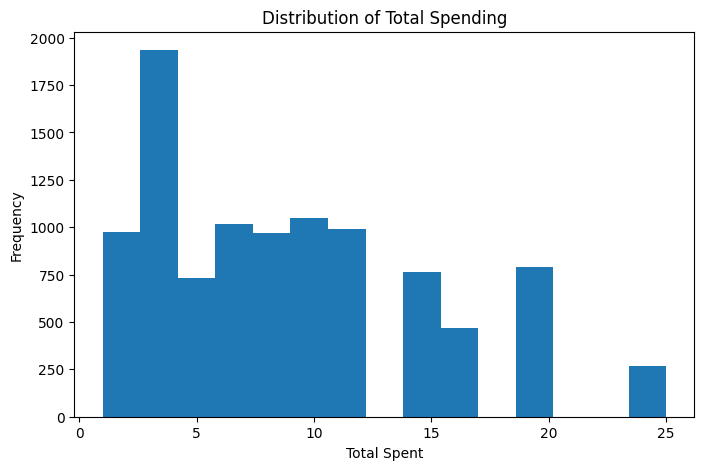

In [109]:
# Histogram is used to visualize the distribution of numerical data.
# Analyze how customer spending is distributed across transactions.
# It help to identify common spending ranges, skewness, and unusual values.

plt.figure(figsize=(8,5))

plt.hist(df["Total Spent"], bins=15)

plt.title("Distribution of Total Spending")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")

plt.show()

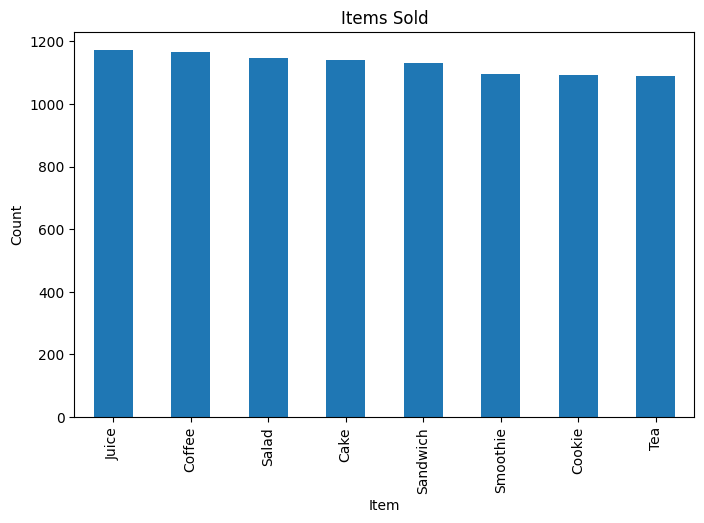

In [110]:
# Bar chart is used for comparing frequencies of categorical data.
# count how many times each item was purchased.
# It help to identify the most and least popular products.

plt.figure(figsize=(8,5))

df["Item"].value_counts().plot(kind="bar")

plt.title("Items Sold")
plt.xlabel("Item")
plt.ylabel("Count")

plt.show()

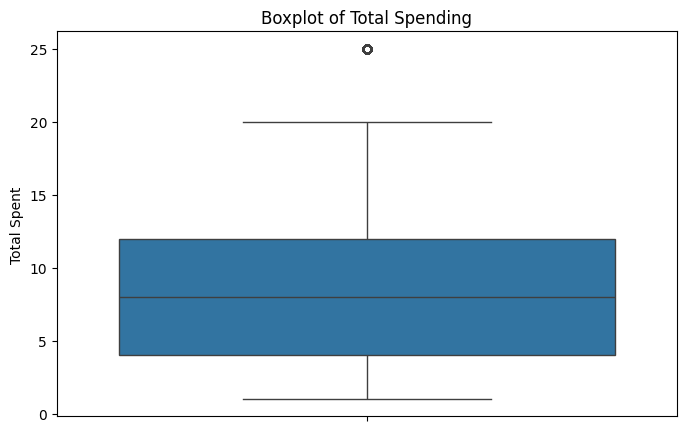

In [111]:
# Box plot is used to detect outliers and understand data spread.
# It shows median, quartiles, minimum, maximum, and potential outliers.
# Useful for checking whether some transactions are unusually high or low.

plt.figure(figsize=(8,5))

sns.boxplot(y=df["Total Spent"])

plt.title("Boxplot of Total Spending")

plt.show()

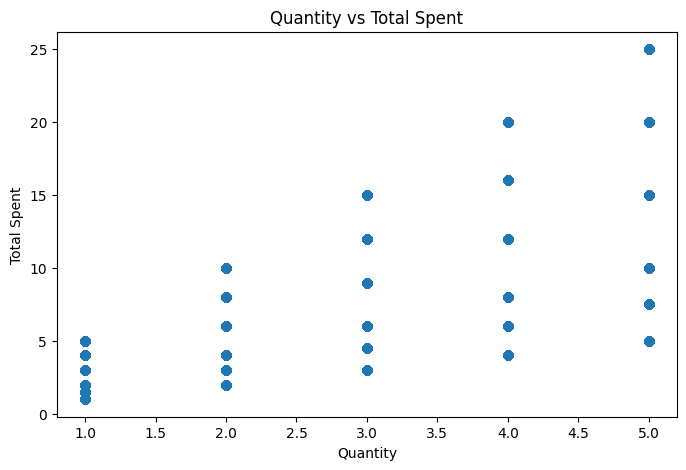

In [112]:
# Scatter plot is used to study relationships between two numerical variables.
#Investigate whether buying more items leads to higher spending.
# Each point represents a transaction.

plt.figure(figsize=(8,5))

plt.scatter(
    df["Quantity"],
    df["Total Spent"]
)

plt.title("Quantity vs Total Spent")
plt.xlabel("Quantity")
plt.ylabel("Total Spent")

plt.show()

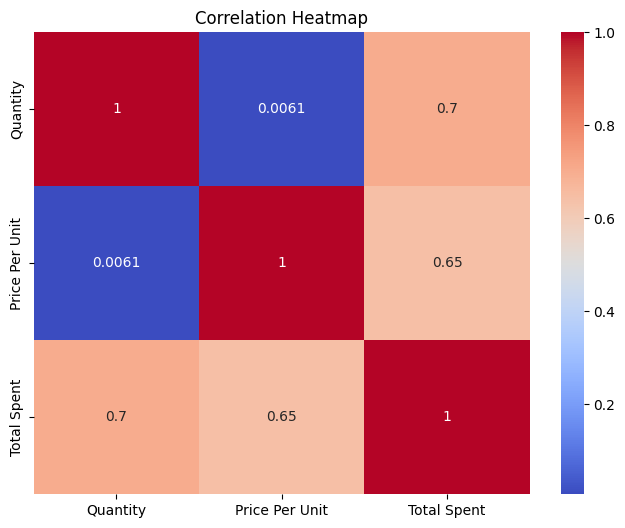

In [113]:
# Correlation heatmap measures the strength of relationships between numerical variables.
# Values close to +1 indicate strong positive relationships.
# Values close to -1 indicate strong negative relationships.
# Values near 0 indicate little or no relationship.

numeric_data = df[
    ["Quantity",
     "Price Per Unit",
     "Total Spent"]
]

corr = numeric_data.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,      # Display correlation values
    cmap="coolwarm"  # Color scheme for visualization
)

plt.title("Correlation Heatmap")

plt.show()

In [114]:
#Does quantity purchased significantly affect total spending?

In [115]:
# Hypotheses
# Null Hypothesis (H₀)

# There is no significant relationship between Quantity and Total Spent.

# Alternative Hypothesis (H₁)

# There is a significant relationship between Quantity and Total Spent.

In [116]:
correlation, p_value = stats.pearsonr(
    df["Quantity"],
    df["Total Spent"]
)

print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: nan
P-value: nan


In [117]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Fail to Reject Null Hypothesis


In [118]:
print(df["Quantity"].isnull().sum())
print(df["Total Spent"].isnull().sum())

479
40


In [119]:
# Fill missing numerical values using median
df["Quantity"] = df["Quantity"].fillna(df["Quantity"].median())
df["Total Spent"] = df["Total Spent"].fillna(df["Total Spent"].median())

In [120]:
print(df["Quantity"].isnull().sum())
print(df["Total Spent"].isnull().sum())

0
0


In [121]:
correlation, p_value = stats.pearsonr(
    df["Quantity"],
    df["Total Spent"]
)

print("Correlation:", correlation)
print("P-value:", p_value)

Correlation: 0.6864657229600981
P-value: 0.0


In [122]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


In [123]:
# A Pearson Correlation Test was conducted to determine whether there is a significant relationship between Quantity Purchased and Total Spent. 
# The test produced a correlation coefficient of r = 0.686 and a p-value = 0.000. 
# Since the p-value is less than the significance level of 0.05, 
# the Null Hypothesis (H₀) is rejected and the Alternative Hypothesis (H₁) is accepted. 
# This indicates that there is a statistically significant positive relationship between Quantity Purchased and Total Spent. 
# The positive correlation suggests that customers who purchase a greater quantity of items tend to spend more money overall.